# Member 2 — Random Forest Biomarker Analysis
## CS690R — IRB Stroke Recovery Dataset

This notebook takes the 228-d kinematic feature matrix produced by Member 1 and:
1. Runs a LOSO Random Forest classifier to validate that the features are discriminative
2. Extracts feature importances to identify which biomarkers matter most
3. Generates figures: feature importance bar chart and violin plots of top biomarkers

---
## 0 — Install Dependencies

In [1]:
import subprocess, sys
for pkg in ['scikit-learn', 'seaborn', 'matplotlib', 'pandas', 'numpy']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

---
## 1 — Imports and Config

In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.model_selection import LeaveOneGroupOut

warnings.filterwarnings('ignore')

# ── Paths ────────────────────────────────────────────────────────────────────
FEATURES_PATH = 'features/biopm_features.npz'
FIGURES_DIR   = 'results/figures'
METRICS_DIR   = 'results/metrics'

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(METRICS_DIR, exist_ok=True)

# ── Plot style ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'  : 'sans-serif',
    'font.size'    : 11,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

GROUP_COLORS = {0: '#2196F3', 1: '#F44336'}   # blue = healthy, red = stroke
GROUP_LABELS = {0: 'Healthy', 1: 'Stroke'}

print('Imports OK')

Imports OK


---
## 2 — Load Features

In [3]:
d = np.load(FEATURES_PATH, allow_pickle=True)

X             = d['features'].astype(np.float64)   # (198, 228)
y             = d['labels'].astype(int)            # (198,)  0=healthy 1=stroke
pids          = d['pids'].astype(int)              # (198,)  subject IDs for LOSO
feature_names = d['feature_names']                 # (228,)  feature name strings

print(f'Feature matrix : {X.shape}')
print(f'Labels         : {np.bincount(y)}  (0=healthy, 1=stroke)')
print(f'Unique subjects: {len(np.unique(pids))}')
print(f'Feature names  : {feature_names[:5]} ...')

Feature matrix : (198, 228)
Labels         : [  4 194]  (0=healthy, 1=stroke)
Unique subjects: 36
Feature names  : ['X_acc_mean_mean' 'X_acc_mean_std' 'X_acc_mean_iqr' 'X_acc_mean_p10'
 'X_acc_mean_p50'] ...


---
## 3 — LOSO Random Forest

Leave-One-Subject-Out cross-validation: in each fold, all visits from one subject
are held out as the test set and the Random Forest is trained on the remaining subjects.

**Why LOSO?** Prevents data leakage across visits from the same person. A standard
train/test split could put visit 1 of subject A in train and visit 3 in test —
the model would learn that person's movement style rather than generalizing across people.

**Why StandardScaler inside the fold?** Scaling must be fit only on training data.
Fitting on all data before splitting would leak test statistics into training.

In [4]:
logo = LeaveOneGroupOut()

all_probs        = np.zeros(len(y))   # pooled predicted probabilities
all_preds        = np.zeros(len(y), dtype=int)
fold_importances = []                 # feature importances per fold
fold_aucs        = []
fold_f1s         = []

n_folds = logo.get_n_splits(X, y, pids)
print(f'Running LOSO with {n_folds} folds (one per subject)...\n')

for fold_idx, (train_idx, test_idx) in enumerate(logo.split(X, y, pids)):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Scale inside fold — fit only on train
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators  = 200,
        class_weight  = 'balanced',   # handles healthy/stroke imbalance
        random_state  = 42,
        n_jobs        = -1,
    )
    rf.fit(X_train, y_train)

    probs = rf.predict_proba(X_test)[:, 1]
    preds = rf.predict(X_test)

    all_probs[test_idx] = probs
    all_preds[test_idx] = preds
    fold_importances.append(rf.feature_importances_)

    # Per-fold metrics (only meaningful when test fold has both classes)
    if len(np.unique(y_test)) > 1:
        fold_aucs.append(roc_auc_score(y_test, probs))
        fold_f1s.append(f1_score(y_test, preds, zero_division=0))

    if (fold_idx + 1) % 10 == 0:
        print(f'  Fold {fold_idx+1}/{n_folds} done')

print('\nDone!')

Running LOSO with 36 folds (one per subject)...

  Fold 10/36 done
  Fold 20/36 done
  Fold 30/36 done

Done!


---
## 4 — Classification Metrics

AUC is computed on **pooled predictions** across all folds — this is the correct
approach for LOSO when many test folds contain only one class (single-visit subjects).
Computing AUC per fold and averaging would give 0.5 for single-class folds.

In [5]:
# Pooled AUC (primary metric)
pooled_auc = roc_auc_score(y, all_probs)
pooled_f1  = f1_score(y, all_preds, zero_division=0)

print('═' * 45)
print('  LOSO Random Forest Results — IRB Dataset')
print('═' * 45)
print(f'  Pooled AUC         : {pooled_auc:.3f}')
print(f'  Pooled F1          : {pooled_f1:.3f}')
if fold_aucs:
    print(f'  Mean per-fold AUC  : {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}')
    print(f'  Mean per-fold F1   : {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}')
print('═' * 45)

# Interpret
if pooled_auc >= 0.80:
    print('  ✅ Strong discrimination (AUC ≥ 0.80)')
elif pooled_auc >= 0.70:
    print('  ✅ Good discrimination (AUC ≥ 0.70)')
elif pooled_auc >= 0.60:
    print('  ⚠️  Moderate discrimination (AUC ≥ 0.60)')
else:
    print('  ❌ Weak discrimination (AUC < 0.60) — investigate labels')

# Save metrics
metrics_df = pd.DataFrame({
    'metric' : ['pooled_auc', 'pooled_f1', 'mean_fold_auc', 'std_fold_auc', 'mean_fold_f1', 'std_fold_f1'],
    'value'  : [
        pooled_auc, pooled_f1,
        np.mean(fold_aucs) if fold_aucs else np.nan,
        np.std(fold_aucs)  if fold_aucs else np.nan,
        np.mean(fold_f1s)  if fold_f1s  else np.nan,
        np.std(fold_f1s)   if fold_f1s  else np.nan,
    ]
})
metrics_df.to_csv(os.path.join(METRICS_DIR, 'rf_loso_results_irb.csv'), index=False)
print(f'\nSaved → results/metrics/rf_loso_results_irb.csv')

═════════════════════════════════════════════
  LOSO Random Forest Results — IRB Dataset
═════════════════════════════════════════════
  Pooled AUC         : 0.780
  Pooled F1          : 0.990
  Mean per-fold AUC  : 0.542 ± 0.390
  Mean per-fold F1   : 0.931 ± 0.004
═════════════════════════════════════════════
  ✅ Good discrimination (AUC ≥ 0.70)

Saved → results/metrics/rf_loso_results_irb.csv


---
## 5 — Feature Importances

Mean Decrease in Impurity (MDI) importances averaged across all LOSO folds.
A feature that consistently ranks highly across folds is a stable biomarker candidate.

In [6]:
# Average importances across all folds
mean_importances = np.mean(fold_importances, axis=0)
std_importances  = np.std(fold_importances,  axis=0)

importance_df = pd.DataFrame({
    'feature'    : feature_names,
    'importance' : mean_importances,
    'std'        : std_importances,
}).sort_values('importance', ascending=False).reset_index(drop=True)

importance_df.to_csv(os.path.join(METRICS_DIR, 'rf_feature_importances_irb.csv'), index=False)

print('Top 15 features by importance:')
print(importance_df.head(15).to_string(index=False))

Top 15 features by importance:
         feature  importance      std
   Y_acc_std_p10    0.041744 0.007248
  Y_jerk_std_p10    0.031531 0.009577
  Y_acc_mean_p90    0.025369 0.006342
  Y_acc_mean_p10    0.024072 0.002235
   Y_vel_std_p90    0.023967 0.005400
   Y_vel_std_iqr    0.020872 0.007065
   Y_acc_max_p10    0.019317 0.005545
 Z_jerk_mean_p50    0.017349 0.003670
  Y_vel_std_mean    0.016868 0.005437
  Y_vel_mean_std    0.015492 0.004977
  Y_jerk_max_p10    0.015452 0.004899
acc_mag_mean_p50    0.015282 0.004950
  Y_vel_mean_p10    0.014667 0.004464
 Y_jerk_mean_iqr    0.014661 0.004145
   Y_vel_max_p90    0.014393 0.004080


---
## 6 — Figure 1: Feature Importance Bar Chart

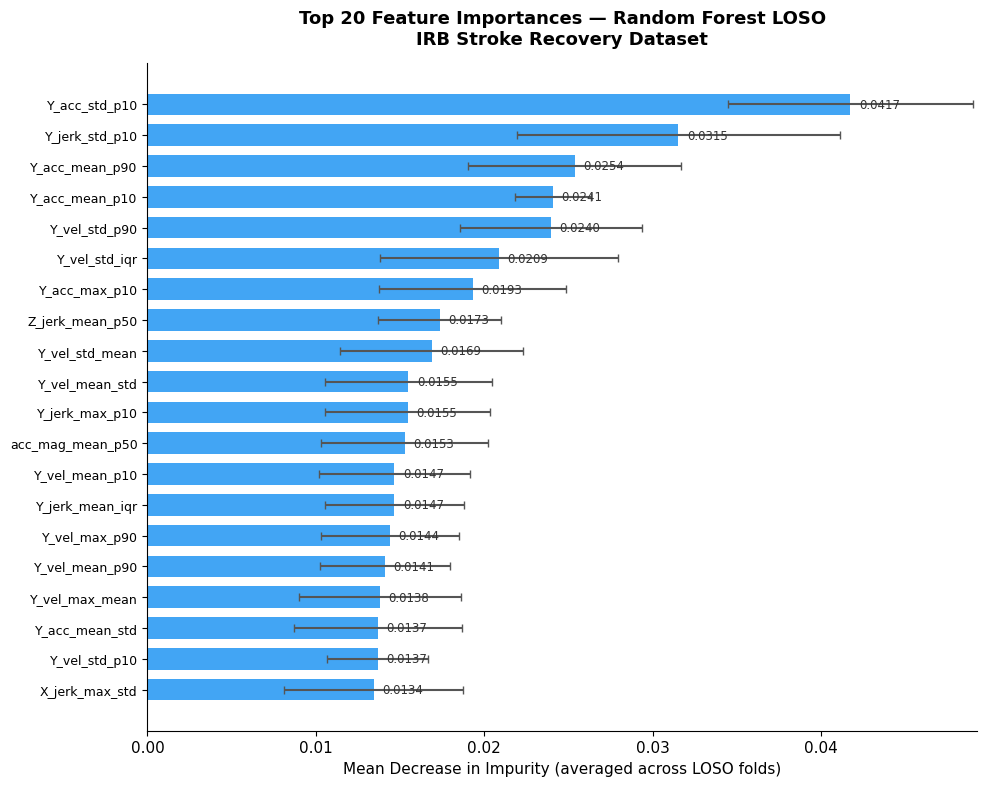

Saved → results/figures\rf_feature_importance_irb.png


In [7]:
TOP_N = 20   # how many features to show

top_df = importance_df.head(TOP_N).iloc[::-1]   # reverse for horizontal bar (highest at top)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    top_df['feature'],
    top_df['importance'],
    xerr=top_df['std'],
    color='#2196F3',
    alpha=0.85,
    ecolor='#555555',
    capsize=3,
    height=0.7,
)

# Annotate bars with importance value
for bar, val in zip(bars, top_df['importance']):
    ax.text(
        bar.get_width() + 0.0005,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.4f}',
        va='center', ha='left', fontsize=8.5, color='#333333'
    )

ax.set_xlabel('Mean Decrease in Impurity (averaged across LOSO folds)', fontsize=11)
ax.set_title(
    f'Top {TOP_N} Feature Importances — Random Forest LOSO\nIRB Stroke Recovery Dataset',
    fontsize=13, fontweight='bold', pad=14
)
ax.set_xlim(0, top_df['importance'].max() * 1.18)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
out = os.path.join(FIGURES_DIR, 'rf_feature_importance_irb.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

---
## 7 — Figure 2: Violin Plots of Top Biomarkers

Visualize the distribution of the top 6 features split by healthy vs. stroke.
A good biomarker should show clearly separated distributions between groups.

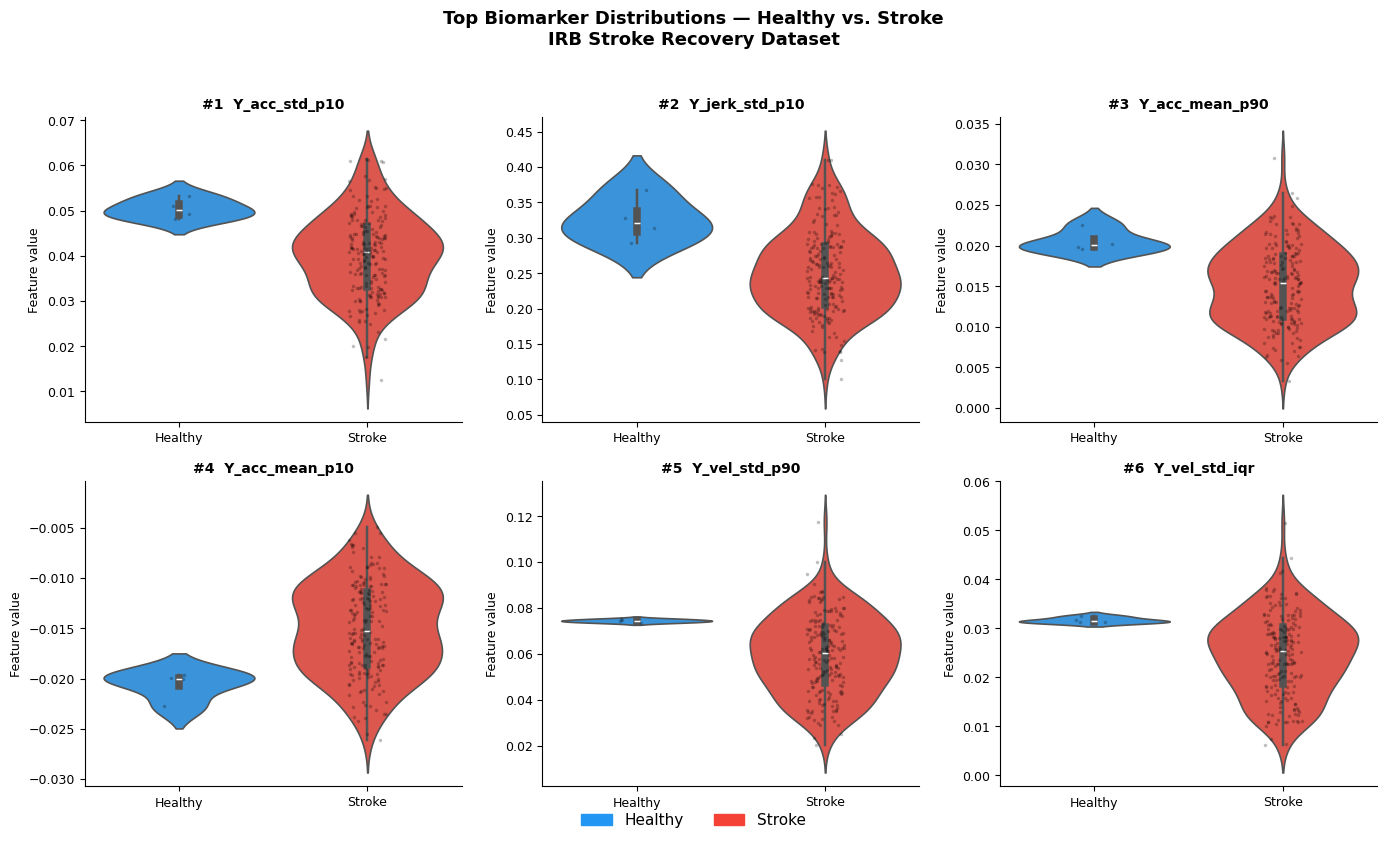

Saved → results/figures\rf_biomarker_distributions_irb.png


In [8]:
TOP_VIOLIN = 6
top_features = importance_df['feature'].head(TOP_VIOLIN).tolist()
top_indices  = [list(feature_names).index(f) for f in top_features]

# Build a long-form DataFrame for seaborn
rows = []
for feat_name, feat_idx in zip(top_features, top_indices):
    for val, label in zip(X[:, feat_idx], y):
        rows.append({'feature': feat_name, 'value': val, 'group': GROUP_LABELS[label]})
plot_df = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

palette = {GROUP_LABELS[0]: GROUP_COLORS[0], GROUP_LABELS[1]: GROUP_COLORS[1]}

for i, feat_name in enumerate(top_features):
    ax  = axes[i]
    sub = plot_df[plot_df['feature'] == feat_name]

    sns.violinplot(
        data=sub, x='group', y='value',
        palette=palette, inner='box',
        order=[GROUP_LABELS[0], GROUP_LABELS[1]],
        ax=ax, linewidth=1.2
    )

    # Overlay individual points
    sns.stripplot(
        data=sub, x='group', y='value',
        order=[GROUP_LABELS[0], GROUP_LABELS[1]],
        color='black', alpha=0.25, size=2.5, jitter=True, ax=ax
    )

    rank = importance_df[importance_df['feature'] == feat_name].index[0] + 1
    ax.set_title(f'#{rank}  {feat_name}', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Feature value', fontsize=9)
    ax.tick_params(labelsize=9)

# Legend
legend_patches = [
    mpatches.Patch(color=GROUP_COLORS[0], label='Healthy'),
    mpatches.Patch(color=GROUP_COLORS[1], label='Stroke'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=2,
           fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    'Top Biomarker Distributions — Healthy vs. Stroke\nIRB Stroke Recovery Dataset',
    fontsize=13, fontweight='bold', y=1.02
)

plt.tight_layout()
out = os.path.join(FIGURES_DIR, 'rf_biomarker_distributions_irb.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

---
## 8 — Output Summary

In [9]:
expected = [
    (os.path.join(METRICS_DIR, 'rf_loso_results_irb.csv'),        'LOSO metrics (AUC, F1)'),
    (os.path.join(METRICS_DIR, 'rf_feature_importances_irb.csv'), 'Ranked feature importances'),
    (os.path.join(FIGURES_DIR, 'rf_feature_importance_irb.png'),   'Feature importance bar chart'),
    (os.path.join(FIGURES_DIR, 'rf_biomarker_distributions_irb.png'), 'Violin plots'),
]

print('Output files:')
for path, desc in expected:
    status = '✅' if os.path.exists(path) else '❌ MISSING'
    print(f'  {status}  {path}  —  {desc}')

print(f'\nPooled AUC : {pooled_auc:.3f}')
print(f'Pooled F1  : {pooled_f1:.3f}')
print(f'Top feature: {importance_df.iloc[0]["feature"]}  (importance={importance_df.iloc[0]["importance"]:.4f})')

Output files:
  ✅  results/metrics\rf_loso_results_irb.csv  —  LOSO metrics (AUC, F1)
  ✅  results/metrics\rf_feature_importances_irb.csv  —  Ranked feature importances
  ✅  results/figures\rf_feature_importance_irb.png  —  Feature importance bar chart
  ✅  results/figures\rf_biomarker_distributions_irb.png  —  Violin plots

Pooled AUC : 0.780
Pooled F1  : 0.990
Top feature: Y_acc_std_p10  (importance=0.0417)
